In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [35]:
df = pd.read_csv("infection_lookup.csv")

In [36]:
df.head()

,infection_id,human_id,infectiousness,days_until_clearance,gametocyte_density
0,517,557,0.027625,150,13.929797
1,606,637,0.001701,35,0.846282
2,607,637,0.001701,35,0.846282
3,608,637,0.001701,35,0.846282
4,609,637,0.001701,35,0.846282


In [37]:
foo = df.groupby("human_id")["infectiousness"].apply(lambda x: 1-np.prod(1-x)).reset_index()
foo.head()

,human_id,infectiousness
0,3,0.210289
1,4,0.369905
2,5,0.292479
3,6,0.396128
4,7,0.298868


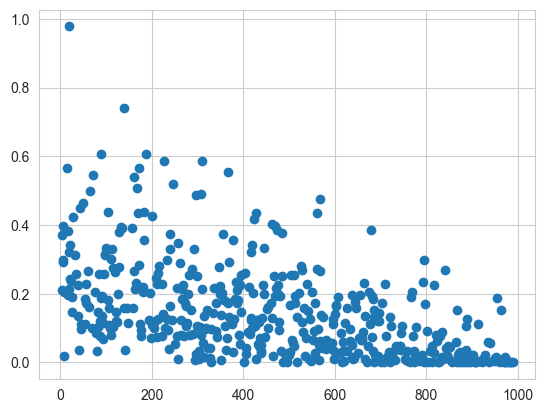

In [38]:
plt.scatter(foo["human_id"], foo["infectiousness"])

In [49]:
h = pd.read_csv("human_lookup.csv")

In [50]:
bar = foo.merge(h, on="human_id", how="left")

In [51]:
bar.head()

,human_id,infectiousness,age,biting_rate,relative_biting_risk,immunity_level
0,3,0.210289,0.227136,0.075460,0.754602,0.000145
1,4,0.369905,0.233057,0.002782,0.027822,0.000008
2,5,0.292479,0.283783,0.186621,1.866205,0.000478
3,6,0.396128,0.295765,0.170556,1.705565,0.000474
4,7,0.298868,0.320929,0.256723,2.567228,0.000787


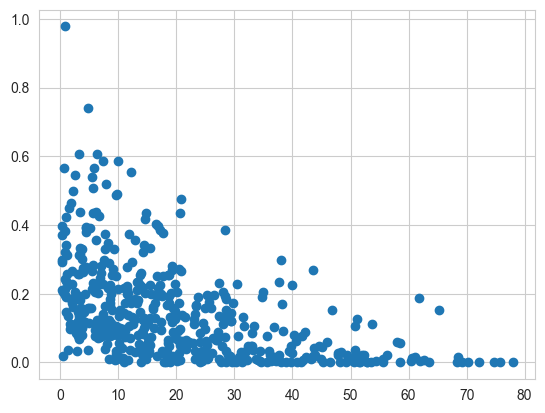

In [52]:
plt.scatter(bar["age"], bar["infectiousness"])

<Axes: xlabel='age', ylabel='infectiousness'>

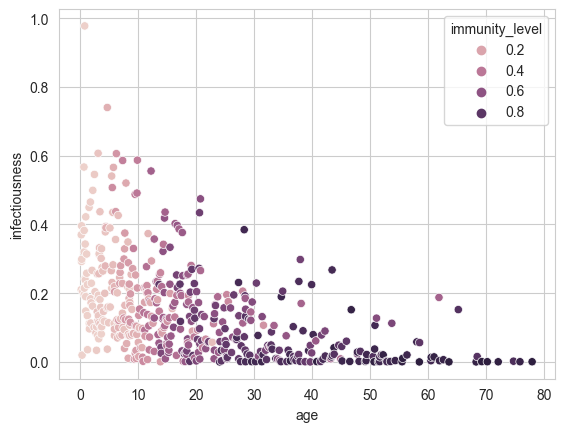

In [43]:
sns.scatterplot(x="age", y="infectiousness", hue="immunity_level", data=bar)

(array([63., 22., 22., 22., 14., 14., 12., 16., 14., 14., 18., 13., 18.,
        16.,  7., 10., 12., 14.,  7., 12., 14.,  8.,  9., 14.,  3.,  5.,
         8.,  8.,  6.,  2.,  5.,  1.,  4.,  4.,  1.,  3.,  2.,  1.,  4.,
         5.,  3.,  1.,  1.,  2.,  5.,  1.,  0.,  1.,  1.,  1.,  1.,  2.,
         0.,  1.,  0.,  2.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([5.65136474e-05, 9.83360218e-03, 1.96106907e-02, 2.93877792e-02,
        3.91648678e-02, 4.89419563e-02, 5.87190448e-02, 6.84961334e-02,
        7.82732219e-02, 8.80503104e-02, 9.78273990e-02, 1.07604487e-01,
        1.17381576e-01, 1.27158665e-01, 1.36935753e-01, 1.46712842e-01,
        1.56489930e-01, 1.66267019e-01, 1.76044107e-01, 1.85821196e-01,
        1.95598284e-01, 2.05375373e-01, 2.15152461e-01, 2.24929550e-01,
  

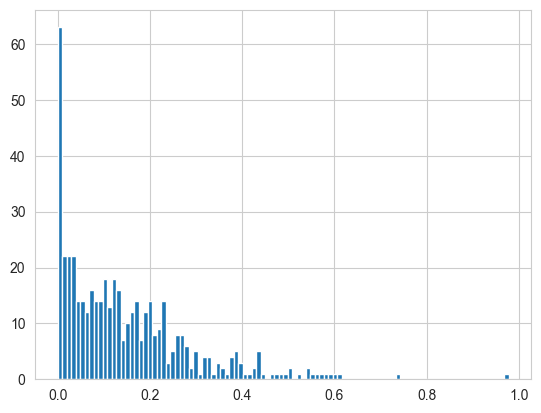

In [44]:
plt.hist(bar["infectiousness"], bins=100)

In [45]:
np.mean(bar["infectiousness"])

0.14614827468574823

In [46]:
# Look at infections in human_id 0
x = df[df["human_id"]==0]

In [47]:
x

,infection_id,human_id,infectiousness,days_until_clearance,gametocyte_density


In [48]:
1-np.prod(1-x["infectiousness"])

0.0